**Mount Google Drive**

In [10]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Import **libraries**

In [12]:

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB2

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**3. Set Random Seeds**

In [17]:
# SET RANDOM SEEDS

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Random seed:", SEED)

Random seed: 42


**4. Define Dataset Paths**

In [18]:
# DEFINE DATASET PATHS

DATASET_DIR = "/content/forest_fire/Forest-Fire-Cleaned/Forest-Fire-Cleaned-dataV2"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

print("Dataset:", DATASET_DIR)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Dataset: /content/forest_fire/Forest-Fire-Cleaned/Forest-Fire-Cleaned-dataV2
Train: /content/forest_fire/Forest-Fire-Cleaned/Forest-Fire-Cleaned-dataV2/train
Validation: /content/forest_fire/Forest-Fire-Cleaned/Forest-Fire-Cleaned-dataV2/val
Test: /content/forest_fire/Forest-Fire-Cleaned/Forest-Fire-Cleaned-dataV2/test


**Step 5 — Verify Dataset Folders**

In [19]:
# VERIFY DATASET

print("Dataset exists:", os.path.exists(DATASET_DIR))
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Validation exists:", os.path.exists(VAL_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

print("\nTrain folders:")
print(os.listdir(TRAIN_DIR))

print("\nValidation folders:")
print(os.listdir(VAL_DIR))

print("\nTest folders:")
print(os.listdir(TEST_DIR))

Dataset exists: True
Train exists: True
Validation exists: True
Test exists: True

Train folders:
['fire', 'nofire']

Validation folders:
['fire', 'nofire']

Test folders:
['fire', 'nofire']


DATASET LOADING

Step 6 — Set Image Parameters **bold text**

In [20]:
# IMAGE PARAMETERS

IMG_SIZE = 260
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: 260
Batch size: 32


**Step 7 — Load Training Dataset**

In [21]:
# LOAD TRAINING DATASET

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("\nClasses:", train_ds.class_names)

Found 600 files belonging to 2 classes.

Classes: ['fire', 'nofire']


**Step 8 — Load Validation Dataset**

In [22]:
# LOAD VALIDATION DATASET

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Validation classes:", val_ds.class_names)

Found 587 files belonging to 2 classes.
Validation classes: ['fire', 'nofire']


**Step 9 — Load Test Dataset**

In [23]:
# LOAD TEST DATASET

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test classes:", test_ds.class_names)

Found 600 files belonging to 2 classes.
Test classes: ['fire', 'nofire']


**Step 10 — Confirm Class Names**

In [24]:
# CHECK CLASS NAMES

print("Training classes:", train_ds.class_names)
print("Validation classes:", val_ds.class_names)
print("Test classes:", test_ds.class_names)

Training classes: ['fire', 'nofire']
Validation classes: ['fire', 'nofire']
Test classes: ['fire', 'nofire']


DATASET ANALYSIS

Step 11 — Count Images in Each Class **bold text**

In [25]:
#  COUNT IMAGES

def count_images(directory):

    counts = {}

    for class_name in sorted(os.listdir(directory)):

        class_path = os.path.join(
            directory,
            class_name
        )

        if os.path.isdir(class_path):

            image_count = len([
                file for file in os.listdir(class_path)
                if file.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".webp")
                )
            ])

            counts[class_name] = image_count

    return counts


train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("TRAIN:")
print(train_counts)

print("\nVALIDATION:")
print(val_counts)

print("\nTEST:")
print(test_counts)

TRAIN:
{'fire': 300, 'nofire': 300}

VALIDATION:
{'fire': 287, 'nofire': 300}

TEST:
{'fire': 300, 'nofire': 300}


**Step 12 — Visualize Class Distribution**

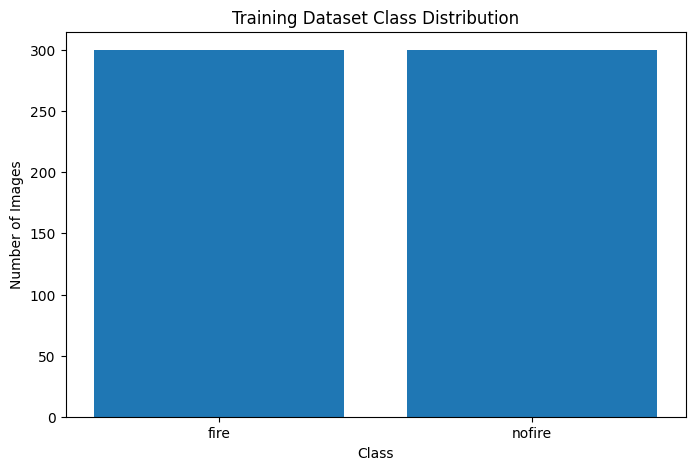

In [26]:
# CLASS DISTRIBUTION

classes = list(train_counts.keys())
counts = list(train_counts.values())

plt.figure(figsize=(8, 5))

plt.bar(classes, counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.show()

VISUAL INSPECTION

Step 13 — Display Training Images **bold text**

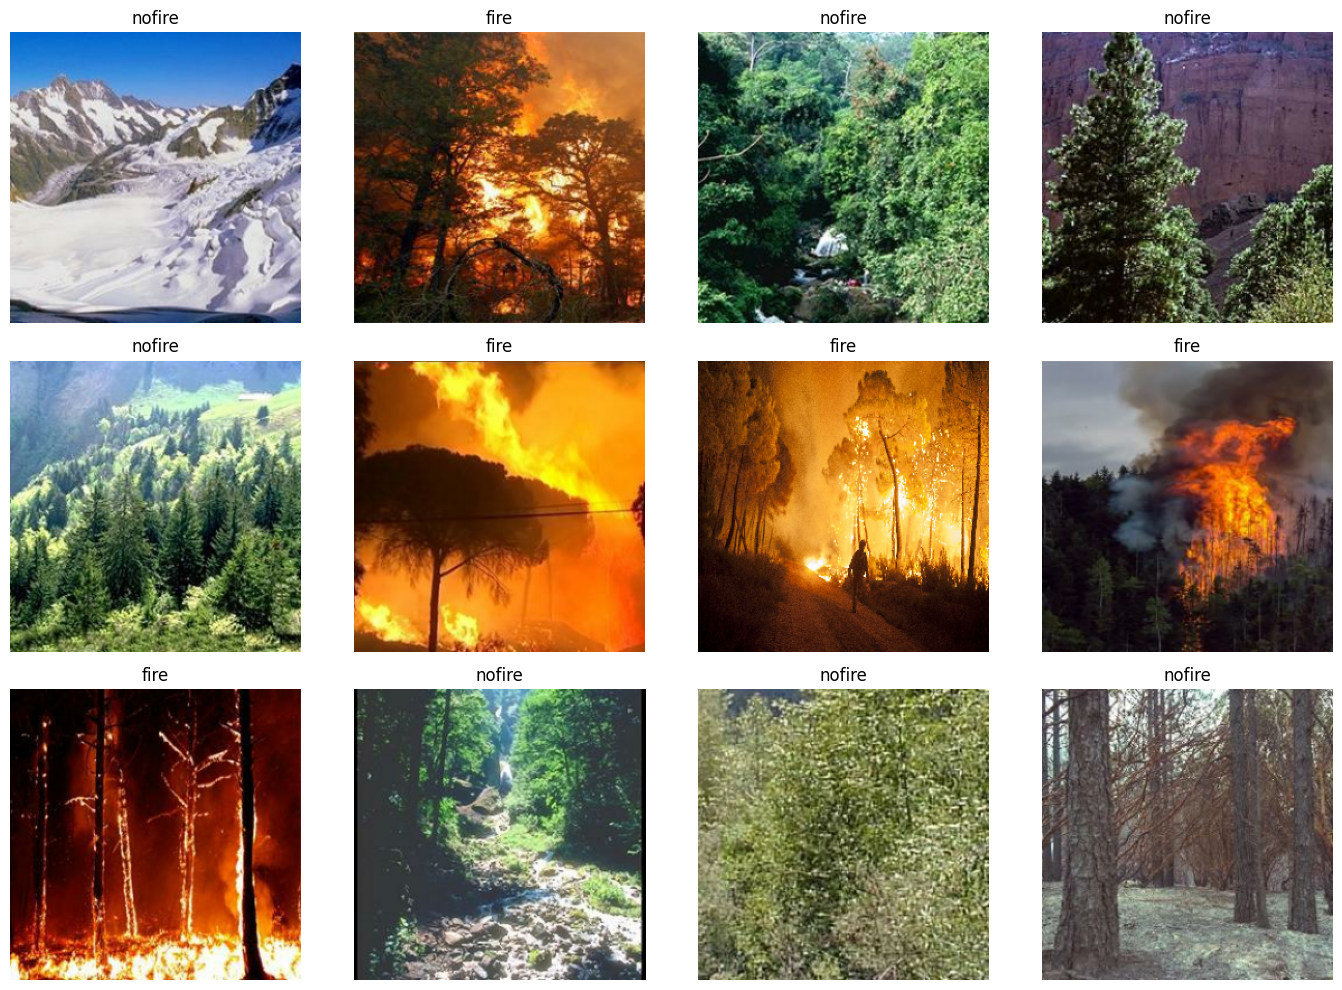

In [27]:
#  DISPLAY SAMPLE TRAINING IMAGES

plt.figure(figsize=(14, 10))

for images, labels in train_ds.take(1):

    for i in range(min(12, len(images))):

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        label = int(labels[i].numpy()[0])

        plt.title(
            train_ds.class_names[label]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

PERFORMANCE OPTIMIZATION

Step 14 — Enable Prefetching **bold text**

In [28]:
#  OPTIMIZE DATA PIPELINE

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    AUTOTUNE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)

test_ds = test_ds.prefetch(
    AUTOTUNE
)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


DATA AUGMENTATION

Step 15 — Create Data Augmentation **bold text**

In [29]:
# STEP 16 — DATA AUGMENTATION

data_augmentation = keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.10
    ),

    layers.RandomZoom(
        0.15
    ),

    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),

    layers.RandomContrast(
        0.15
    )

], name="data_augmentation")

print("Data augmentation created.")

Data augmentation created.


**Step 16 — Visualize Augmentation**

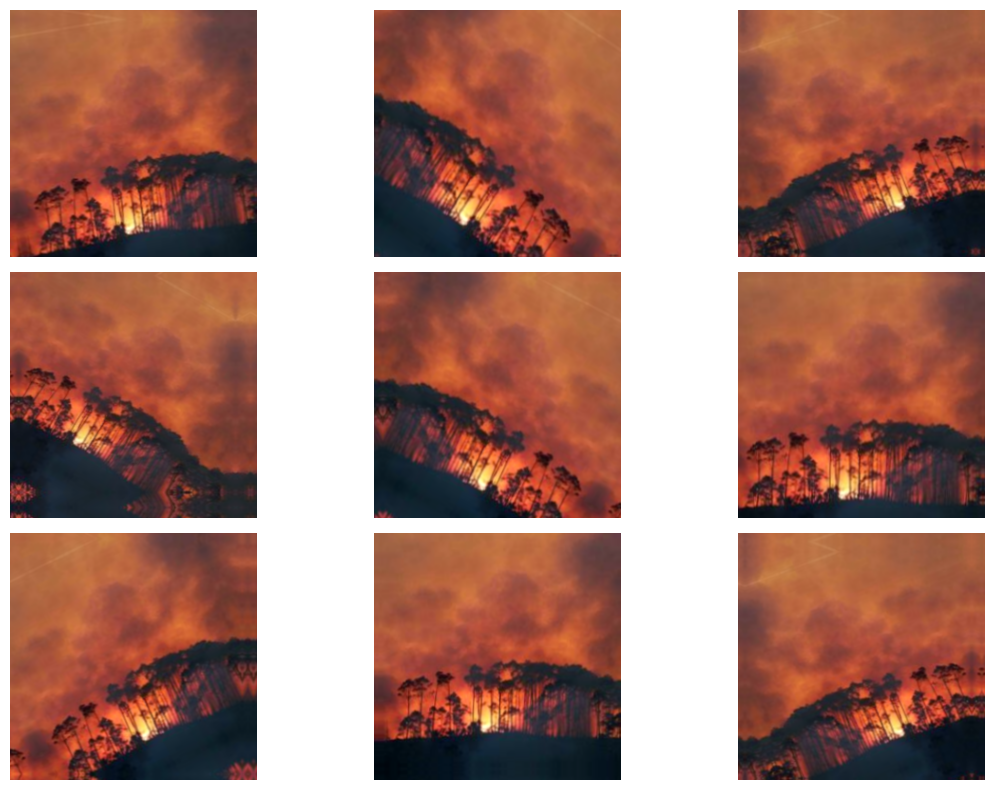

In [30]:
# VISUALIZE AUGMENTATION

for images, labels in train_ds.take(1):

    sample_image = images[0]

    plt.figure(figsize=(12, 8))

    for i in range(9):

        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

    break

CLASS WEIGHTS

Step 17 — Calculate Class Weights **bold text**

In [31]:
# CALCULATE CLASS WEIGHTS

total_images = sum(train_counts.values())
num_classes = len(train_counts)

class_weights = {}

for index, class_name in enumerate(
    sorted(train_counts.keys())
):

    class_count = train_counts[class_name]

    class_weights[index] = (
        total_images /
        (num_classes * class_count)
    )

print("Class weights:")

for index, weight in class_weights.items():

    print(
        f"Class {index} "
        f"({sorted(train_counts.keys())[index]}): "
        f"{weight:.4f}"
    )

Class weights:
Class 0 (fire): 1.0000
Class 1 (nofire): 1.0000


MODEL

Step 18 — Load EfficientNetB2 **bold text**

In [32]:
# LOAD PRETRAINED EFFICIENTNETB2

base_model = EfficientNetB2(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

print("EfficientNetB2 loaded.")

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
EfficientNetB2 loaded.


**Step 19 — Freeze Base Model**

In [33]:
#  FREEZE PRETRAINED MODEL

base_model.trainable = False

print(
    "Trainable:",
    base_model.trainable
)

Trainable: False


**Step 20 — Build Classification Model**

In [34]:
#  BUILD FOREST FIRE CLASSIFIER

inputs = keras.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.35)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.25)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = keras.Model(
    inputs,
    outputs,
    name="Forest_Fire_EfficientNetB2"
)

model.summary()

Model: "Forest_Fire_EfficientNetB2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       180,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,954,682 (30.34 MB)

 Trainable params: 183,297 (716.00 KB)

 Non-trainable params: 7,771,385 (29.65 MB)

COMPILATION

Step 21 — Compile Model **bold text**

In [35]:
# COMPILE MODEL

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=keras.losses.BinaryCrossentropy(),

    metrics=[

        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        ),

        keras.metrics.AUC(
            name="auc"
        )
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


CALLBACKS

Step 22 — Create Model Saving Directory **bold text**

In [36]:
#  CREATE MODEL DIRECTORY

MODEL_DIR = "/content/drive/MyDrive/forest_fire_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

print("Model directory:", MODEL_DIR)

Model directory: /content/drive/MyDrive/forest_fire_models


**Step 23 — Create Training Callbacks**

In [37]:
#  TRAINING CALLBACKS

callbacks = [

    keras.callbacks.ModelCheckpoint(

        filepath=os.path.join(
            MODEL_DIR,
            "best_forest_fire_model.keras"
        ),

        monitor="val_loss",

        save_best_only=True,

        mode="min",

        verbose=1
    ),

    keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=7,

        mode="min",

        restore_best_weights=True,

        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.3,

        patience=3,

        min_lr=1e-7,

        mode="min",

        verbose=1
    )
]

print("Callbacks ready.")

Callbacks ready.


STAGE 1 TRAINING

Step 24 — Train Classification Head **bold text**

In [38]:
# STAGE 1 TRAINING

EPOCHS_STAGE1 = 15

history_stage1 = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS_STAGE1,

    class_weight=class_weights,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7940 - auc: 0.8964 - loss: 0.4310 - precision: 0.7392 - recall: 0.9566
Epoch 1: val_loss improved from None to 0.23985, saving model to /content/drive/MyDrive/forest_fire_models/best_forest_fire_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/forest_fire_models/best_forest_fire_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 881ms/step - accuracy: 0.8967 - auc: 0.9751 - loss: 0.2354 - precision: 0.8459 - recall: 0.9700 - val_accuracy: 0.9233 - val_auc: 0.9679 - val_loss: 0.2399 - val_precision: 0.9474 - val_recall: 0.9000 - learning_rate: 0.0010
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9714 - auc: 0.9930 - loss: 0.0857 - precision: 0.9683 - recall: 0.9760
Epoch 2: val_loss improved from 0.23985 to 0.23072, saving model to /content/drive/MyDrive/forest_fire_models/best_forest_fire_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/forest_fire_models/best_forest_

FINE-TUNING

Step 25 — Unfreeze EfficientNet **bold text**

In [39]:
# UNFREEZE LAST PART OF EFFICIENTNET

base_model.trainable = True

# Freeze earlier layers
for layer in base_model.layers[:-40]:

    layer.trainable = False

print(
    "Total layers:",
    len(base_model.layers)
)

print(
    "Last 40 layers are trainable."
)

Total layers: 340
Last 40 layers are trainable.


**Step 26 — Recompile with Small Learning Rate**

In [40]:
# RECOMPILE FOR FINE-TUNING

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=keras.losses.BinaryCrossentropy(),

    metrics=[

        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        ),

        keras.metrics.AUC(
            name="auc"
        )
    ]
)

print("Fine-tuning configuration ready.")

Fine-tuning configuration ready.


**Step 27 — Fine-Tune Model**

In [41]:
# STAGE 2 FINE-TUNING

EPOCHS_STAGE2 = 30

history_stage2 = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS_STAGE2,

    class_weight=class_weights,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9271 - auc: 0.9860 - loss: 0.1593 - precision: 0.9236 - recall: 0.9259
Epoch 1: val_loss improved from 0.16837 to 0.16758, saving model to /content/drive/MyDrive/forest_fire_models/best_forest_fire_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/forest_fire_models/best_forest_fire_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 35s 687ms/step - accuracy: 0.9300 - auc: 0.9853 - loss: 0.1573 - precision: 0.9272 - recall: 0.9333 - val_accuracy: 0.9523 - val_auc: 0.9710 - val_loss: 0.1676 - val_precision: 0.9416 - val_recall: 0.9667 - learning_rate: 1.0000e-05
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9352 - auc: 0.9891 - loss: 0.1494 - precision: 0.8954 - recall: 0.9771
Epoch 2: val_loss did not improve from 0.16758
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 373ms/step - accuracy: 0.9517 - auc: 0.9904 - loss: 0.1289 - precision: 0.9302 - recall: 0.9767 - val_accuracy: 0.9574 - val_auc: 0.9707 - val_l

TRAINING ANALYSIS

Step 28 — Combine Training Histories

In [42]:
# COMBINE TRAINING HISTORIES

accuracy = (
    history_stage1.history["accuracy"]
    +
    history_stage2.history["accuracy"]
)

val_accuracy = (
    history_stage1.history["val_accuracy"]
    +
    history_stage2.history["val_accuracy"]
)

loss = (
    history_stage1.history["loss"]
    +
    history_stage2.history["loss"]
)

val_loss = (
    history_stage1.history["val_loss"]
    +
    history_stage2.history["val_loss"]
)

precision = (
    history_stage1.history["precision"]
    +
    history_stage2.history["precision"]
)

val_precision = (
    history_stage1.history["val_precision"]
    +
    history_stage2.history["val_precision"]
)

recall = (
    history_stage1.history["recall"]
    +
    history_stage2.history["recall"]
)

val_recall = (
    history_stage1.history["val_recall"]
    +
    history_stage2.history["val_recall"]
)

**Step 29 — Plot Accuracy**

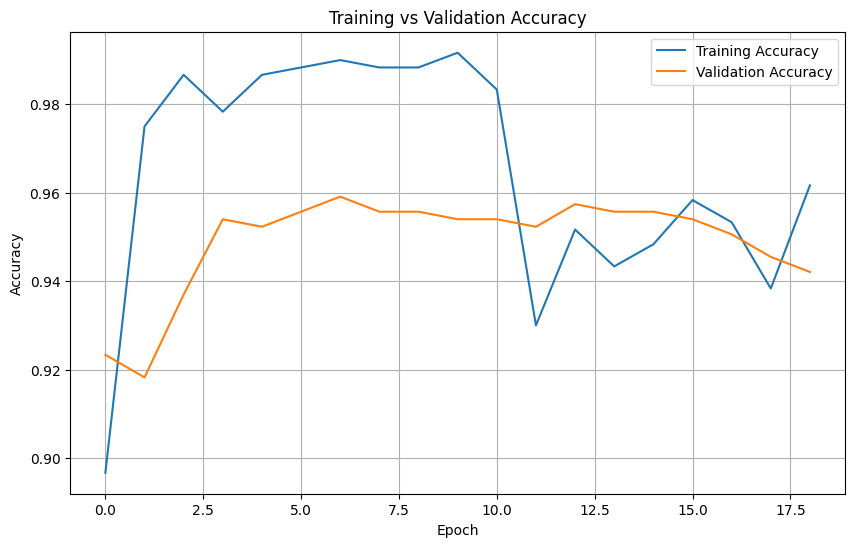

In [43]:
#  ACCURACY CURVE

plt.figure(figsize=(10, 6))

plt.plot(
    accuracy,
    label="Training Accuracy"
)

plt.plot(
    val_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

**Step 30 — Plot Loss**

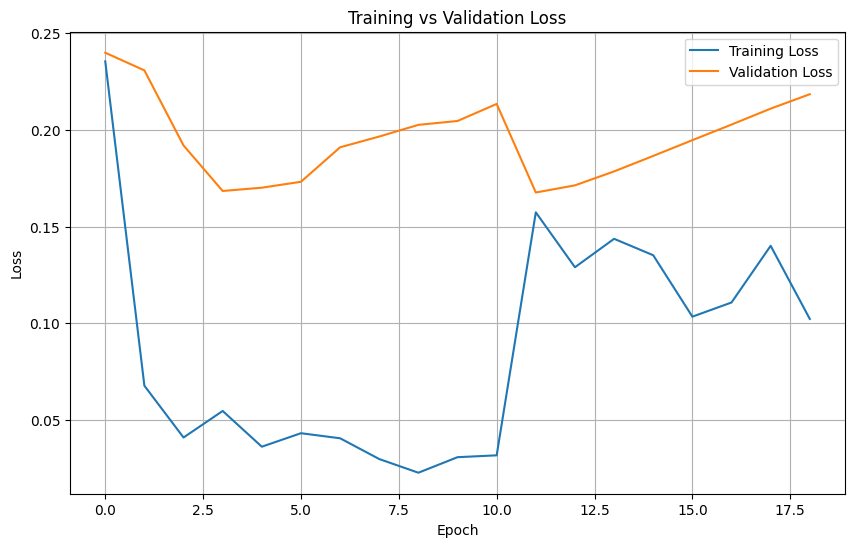

In [44]:
# LOSS CURVE

plt.figure(figsize=(10, 6))

plt.plot(
    loss,
    label="Training Loss"
)

plt.plot(
    val_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

**Step 31 — Plot Precision**

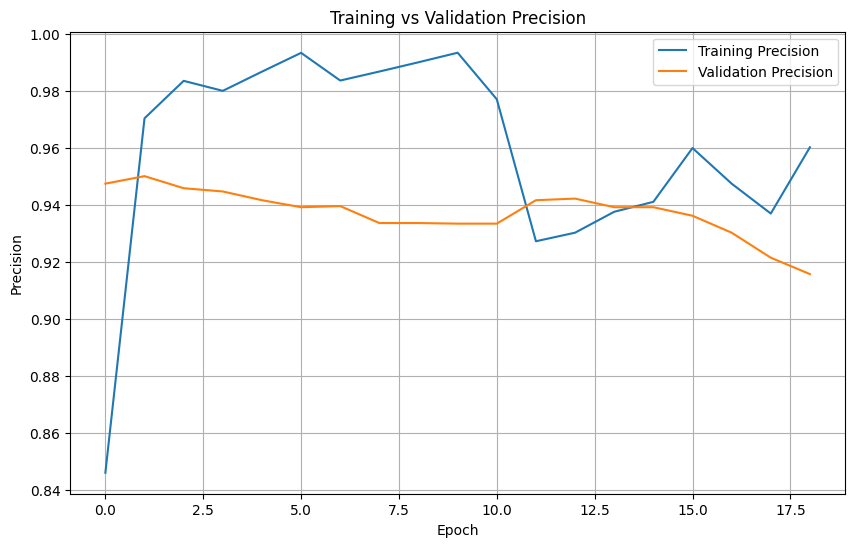

In [45]:
# PRECISION CURVE

plt.figure(figsize=(10, 6))

plt.plot(
    precision,
    label="Training Precision"
)

plt.plot(
    val_precision,
    label="Validation Precision"
)

plt.xlabel("Epoch")
plt.ylabel("Precision")

plt.title(
    "Training vs Validation Precision"
)

plt.legend()
plt.grid(True)

plt.show()

**Step 32 — Plot Recall**

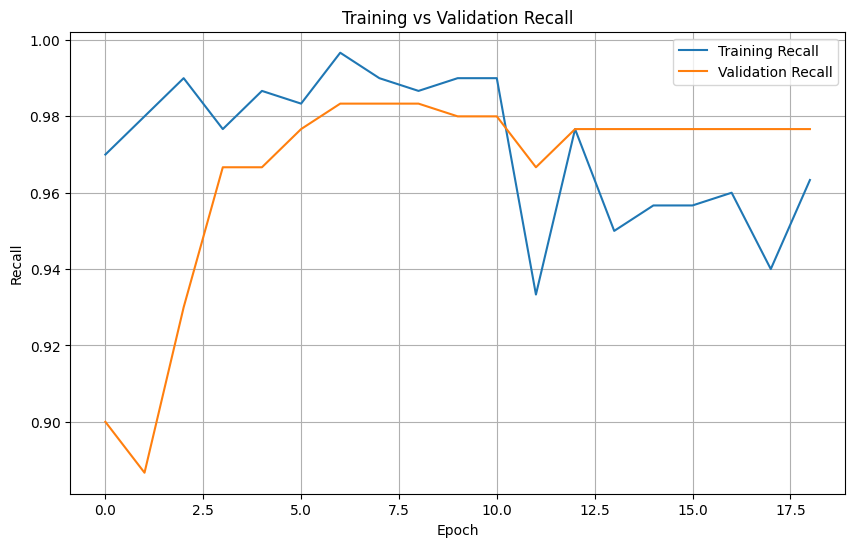

In [46]:
# RECALL CURVE

plt.figure(figsize=(10, 6))

plt.plot(
    recall,
    label="Training Recall"
)

plt.plot(
    val_recall,
    label="Validation Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.title(
    "Training vs Validation Recall"
)

plt.legend()
plt.grid(True)

plt.show()

BEST MODEL

Step 33 — Load Best Saved Model **bold text**

In [47]:
# LOAD BEST MODEL

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_forest_fire_model.keras"
)

best_model = keras.models.load_model(
    BEST_MODEL_PATH
)

print("Best model loaded.")
print(BEST_MODEL_PATH)

Best model loaded.
/content/drive/MyDrive/forest_fire_models/best_forest_fire_model.keras


FINAL TEST

Step 34 — Evaluate Test Dataset **bold text**

In [48]:
# FINAL TEST EVALUATION

test_results = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\n===== TEST RESULTS =====")

for metric_name, value in zip(
    best_model.metrics_names,
    test_results
):

    print(
        f"{metric_name}: {value:.4f}"
    )

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.9583 - auc: 0.9960 - loss: 0.0978 - precision: 0.9599 - recall: 0.9567

===== TEST RESULTS =====
loss: 0.0978
compile_metrics: 0.9583


PREDICTIONS

Step 35 — Generate Test Predictions **bold text**

In [49]:
# GENERATE TEST PREDICTIONS

y_true = []
y_prob = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    y_prob.extend(
        predictions.flatten()
    )

    y_true.extend(
        labels.numpy().flatten()
    )

y_true = np.array(y_true)
y_prob = np.array(y_prob)

print("Predictions generated.")
print("Number of test images:", len(y_true))

Predictions generated.
Number of test images: 600


METRICS

Step 36 — Calculate Accuracy, Precision, Recall, F1 **bold text**

In [50]:
#  CALCULATE FINAL METRICS

y_pred = (
    y_prob >= 0.5
).astype(int)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

auc = roc_auc_score(
    y_true,
    y_prob
)

print("====================================")
print("🔥 FINAL FOREST FIRE PERFORMANCE")
print("====================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

🔥 FINAL FOREST FIRE PERFORMANCE
Accuracy : 0.9583
Precision: 0.9599
Recall   : 0.9567
F1 Score : 0.9583
ROC-AUC  : 0.9960


CLASSIFICATION REPORT

Step 37 — Classification Report **bold text**

In [51]:
#  CLASSIFICATION REPORT

print(
    classification_report(

        y_true,

        y_pred,

        target_names=[
            "fire",
            "no_fire"
        ],

        digits=4
    )
)

              precision    recall  f1-score   support

        fire     0.9568    0.9600    0.9584       300
     no_fire     0.9599    0.9567    0.9583       300

    accuracy                         0.9583       600
   macro avg     0.9583    0.9583    0.9583       600
weighted avg     0.9583    0.9583    0.9583       600



CONFUSION MATRIX

Step 38 — Confusion Matrix **bold text**

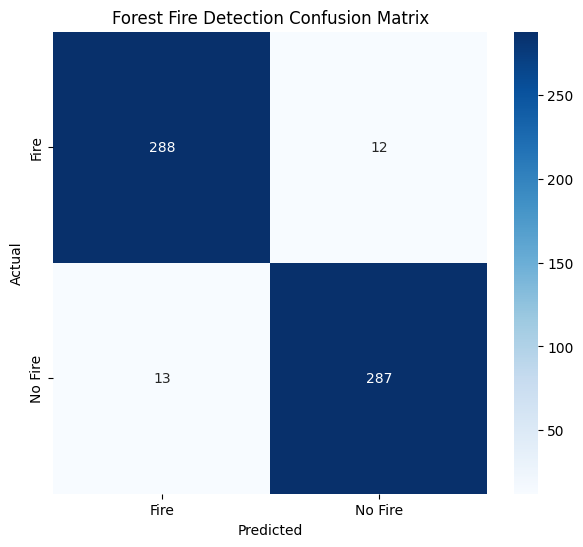

In [52]:
#  CONFUSION MATRIX

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Fire",
        "No Fire"
    ],

    yticklabels=[
        "Fire",
        "No Fire"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Forest Fire Detection Confusion Matrix"
)

plt.show()

ROC CURVE

Step 39 — ROC-AUC Curve **bold text**

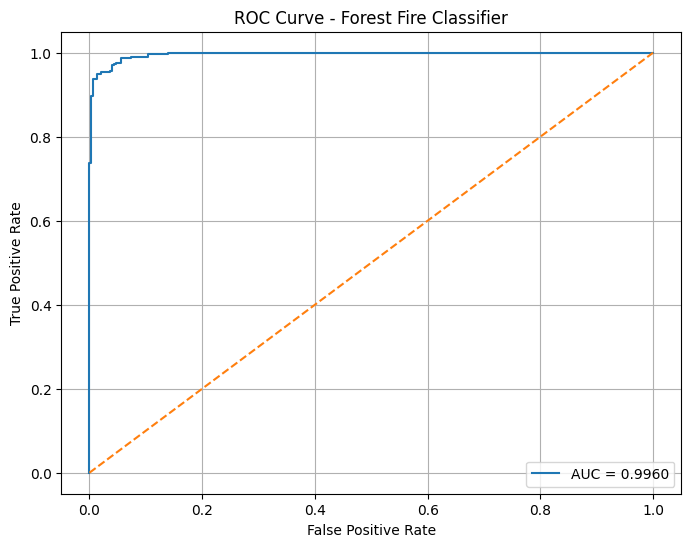

In [53]:
#  ROC CURVE

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Forest Fire Classifier"
)

plt.legend()

plt.grid(True)

plt.show()

SAVE FINAL MODEL

Step 40 — Save Final Model **bold text**

In [54]:
#  SAVE FINAL MODEL

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "forest_fire_classifier.keras"
)

best_model.save(
    FINAL_MODEL_PATH
)

print("🔥 Final model saved successfully!")
print(FINAL_MODEL_PATH)

🔥 Final model saved successfully!
/content/drive/MyDrive/forest_fire_models/forest_fire_classifier.keras


SAVE CLASS NAMES

Step 41 — Save Class Names **bold text**

In [56]:
# STEP 42 — SAVE CLASS NAMES

class_names = ["fire", "no_fire"]

CLASS_NAMES_PATH = os.path.join(
    MODEL_DIR,
    "class_names.json"
)

with open(
    CLASS_NAMES_PATH,
    "w"
) as file:

    json.dump(
        class_names,
        file
    )

print("Class names:", class_names)
print("Saved to:", CLASS_NAMES_PATH)

Class names: ['fire', 'no_fire']
Saved to: /content/drive/MyDrive/forest_fire_models/class_names.json


SINGLE IMAGE PREDICTION

Step 42 — Create Prediction Function **bold text**

In [57]:
# SINGLE IMAGE PREDICTION FUNCTION

from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array

def predict_fire(image_path):

    image = load_img(
        image_path,
        target_size=(
            IMG_SIZE,
            IMG_SIZE
        )
    )

    image_array = img_to_array(
        image
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probability = float(
        best_model.predict(
            image_array,
            verbose=0
        )[0][0]
    )

    predicted_index = int(
        probability >= 0.5
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = (
        probability
        if predicted_index == 1
        else 1 - probability
    )

    return predicted_class, confidence

TEST ONE IMAGE
Step 43 — Predict an Image **bold text**

Saving F_31.jpg to F_31.jpg
Uploaded image: F_31.jpg


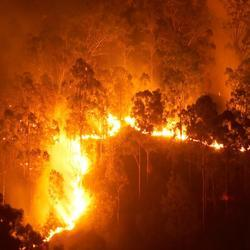


🔥 FOREST FIRE DETECTOR
Prediction : FIRE
Confidence : 99.95%


In [63]:
# STEP 44 — UPLOAD AND TEST A NEW IMAGE

from google.colab import files
from IPython.display import display
from PIL import Image

# Upload image
uploaded = files.upload()

# Get uploaded filename
IMAGE_PATH = next(iter(uploaded))

print("Uploaded image:", IMAGE_PATH)

# Open and display image
image = Image.open(IMAGE_PATH)

display(image)

# Predict
prediction, confidence = predict_fire(
    IMAGE_PATH
)

print("\n====================================")
print("🔥 FOREST FIRE DETECTOR")
print("====================================")

print(f"Prediction : {prediction.upper()}")
print(f"Confidence : {confidence * 100:.2f}%")

print("====================================")

FIND BEST CLASSIFICATION THRESHOLD

Step 44 — Optimize Decision Threshold

In [59]:
#  FIND BEST F1 THRESHOLD

thresholds_to_test = np.arange(
    0.10,
    0.91,
    0.01
)

best_threshold = 0.5
best_f1 = 0

for threshold in thresholds_to_test:

    predictions = (
        y_prob >= threshold
    ).astype(int)

    current_f1 = f1_score(
        y_true,
        predictions
    )

    if current_f1 > best_f1:

        best_f1 = current_f1
        best_threshold = threshold

print(
    f"Best Threshold: {best_threshold:.2f}"
)

print(
    f"Best F1 Score: {best_f1:.4f}"
)

Best Threshold: 0.70
Best F1 Score: 0.9677


FINAL REPORT WITH BEST THRESHOLD

Step 45 — Evaluate Optimized Threshold **bold text**

In [60]:
#  FINAL OPTIMIZED THRESHOLD RESULTS

optimized_pred = (
    y_prob >= best_threshold
).astype(int)

optimized_accuracy = accuracy_score(
    y_true,
    optimized_pred
)

optimized_precision = precision_score(
    y_true,
    optimized_pred
)

optimized_recall = recall_score(
    y_true,
    optimized_pred
)

optimized_f1 = f1_score(
    y_true,
    optimized_pred
)

print("==========================================")
print("🔥 OPTIMIZED FOREST FIRE MODEL")
print("==========================================")

print(
    f"Threshold : {best_threshold:.2f}"
)

print(
    f"Accuracy  : {optimized_accuracy:.4f}"
)

print(
    f"Precision : {optimized_precision:.4f}"
)

print(
    f"Recall    : {optimized_recall:.4f}"
)

print(
    f"F1 Score  : {optimized_f1:.4f}"
)

print(
    f"ROC-AUC   : {auc:.4f}"
)

🔥 OPTIMIZED FOREST FIRE MODEL
Threshold : 0.70
Accuracy  : 0.9683
Precision : 0.9862
Recall    : 0.9500
F1 Score  : 0.9677
ROC-AUC   : 0.9960


**final step : save model in your pc**

In [64]:
# STEP 49 — DOWNLOAD MODEL TO PC

from google.colab import files

MODEL_PATH = "/content/drive/MyDrive/forest_fire_models/forest_fire_classifier.keras"

files.download(MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>